# 🚀 NASA C-MAPSS Turbofan: Missingness, Imputation & RUL Benchmark Pipeline

This notebook implements the complete 8-stage roadmap:
1. **EDA & Signal Understanding** (Load FD001, visualize degradation trajectories, drop flat sensors)
2. **Build RUL Labels** (Calculate piece-wise linear clipped RUL target at 125 cycles)
3. **Preprocessing** (Z-score scaling strictly fitted on train data)
4. **Missingness Experiment Design** (Inject controlled MCAR, MAR, MNAR, and Block Dropouts)
5. **Imputation Algorithms** (Forward-fill, Grouped Linear Interpolation, KNN, and MICE)
6. **Direct Imputation Evaluation** (RMSE and MAE against masked ground truth)
7. **RUL Modeling** (Sliding Window Sequence Extraction + PyTorch/TensorFlow or Regressor)
8. **Downstream Impact Evaluation** (Test RUL RMSE & Asymmetric PHM 2008 Score under different missing rates)

## 📦 Step 0: Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)
print("Setup complete.")

Setup complete.


## 📊 Step 1: Exploratory Data Analysis & Understanding the Signal

In [2]:
# Column names per documentation
index_cols = ['unit_nr', 'time_cycles']
setting_cols = ['setting_1', 'setting_2', 'setting_3']
sensor_cols = [f's_{i}' for i in range(1, 22)]
all_cols = index_cols + setting_cols + sensor_cols

# Load FD001 train and test
train_df = pd.read_csv('train_FD001.txt', sep=r'\s+', header=None, names=all_cols)
test_df = pd.read_csv('test_FD001.txt', sep=r'\s+', header=None, names=all_cols)
rul_test = pd.read_csv('RUL_FD001.txt', sep=r'\s+', header=None, names=['true_rul'])

print(f"Train shape: {train_df.shape} ({train_df['unit_nr'].nunique()} engines)")
print(f"Test shape: {test_df.shape} ({test_df['unit_nr'].nunique()} engines)")

# Check standard deviation across all sensors to identify constant/invariant sensors
sensor_stds = train_df[sensor_cols].std()
constant_sensors = sensor_stds[sensor_stds < 0.01].index.tolist()
active_sensors = [s for s in sensor_cols if s not in constant_sensors]

print(f"\nNear-constant sensors (low/zero variance): {constant_sensors}")
print(f"Active degradation sensors ({len(active_sensors)}): {active_sensors}")

Train shape: (20631, 26) (100 engines)
Test shape: (13096, 26) (100 engines)

Near-constant sensors (low/zero variance): ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
Active degradation sensors (14): ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']


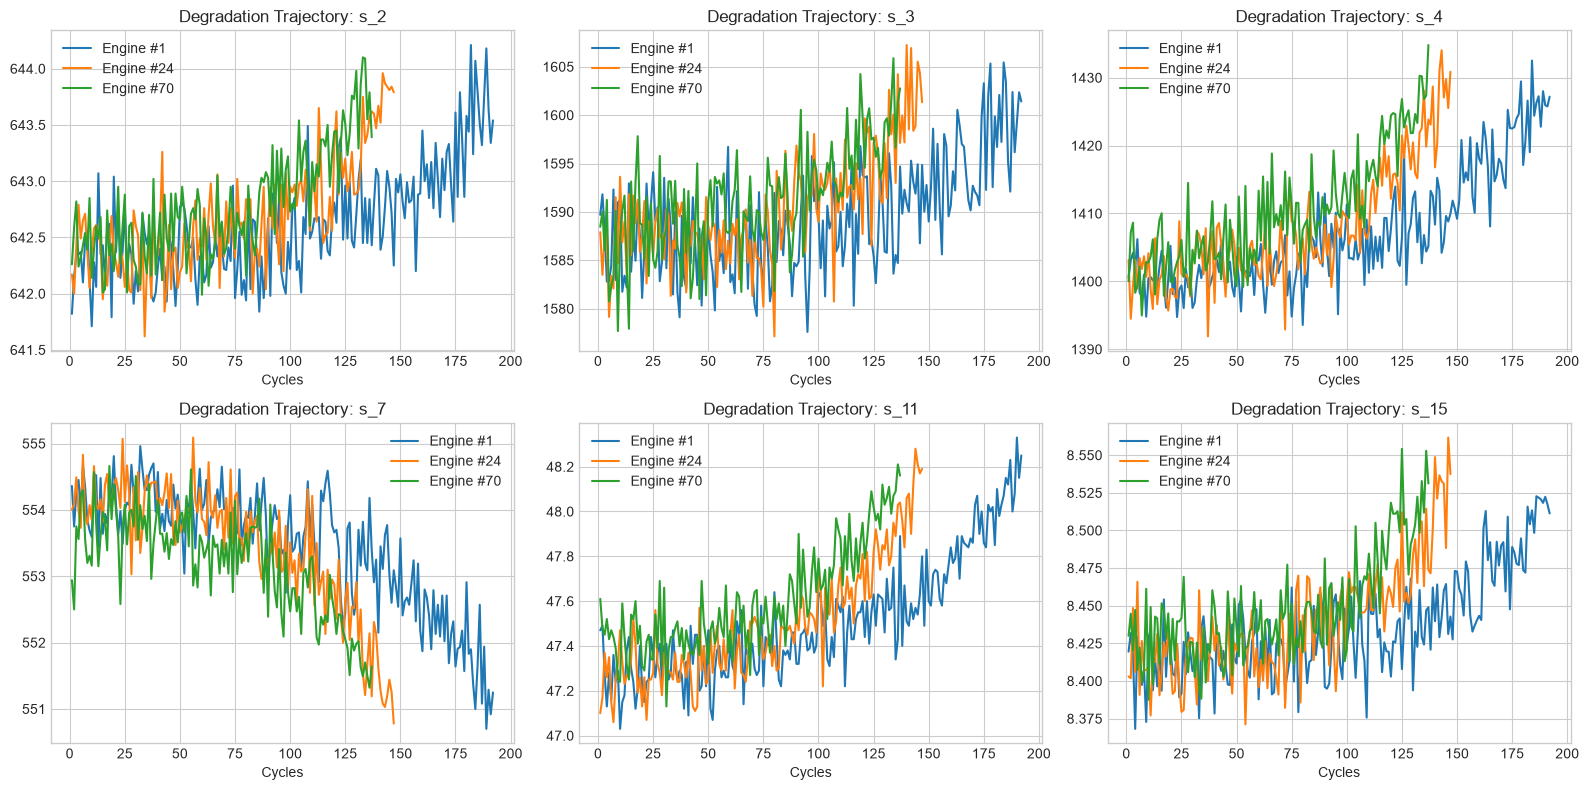

In [3]:
# Plot lifetime degradation trajectories for selected engines across active sensors
sample_units = [1, 24, 70]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
sample_sensors = ['s_2', 's_3', 's_4', 's_7', 's_11', 's_15']

for ax, sensor in zip(axes.flatten(), sample_sensors):
    for unit in sample_units:
        unit_data = train_df[train_df['unit_nr'] == unit]
        ax.plot(unit_data['time_cycles'], unit_data[sensor], label=f'Engine #{unit}')
    ax.set_title(f'Degradation Trajectory: {sensor}')
    ax.set_xlabel('Cycles')
    ax.legend()

plt.tight_layout()
plt.show()

## 🏷️ Step 2: Build RUL Labels (Piecewise-Linear Clipping)

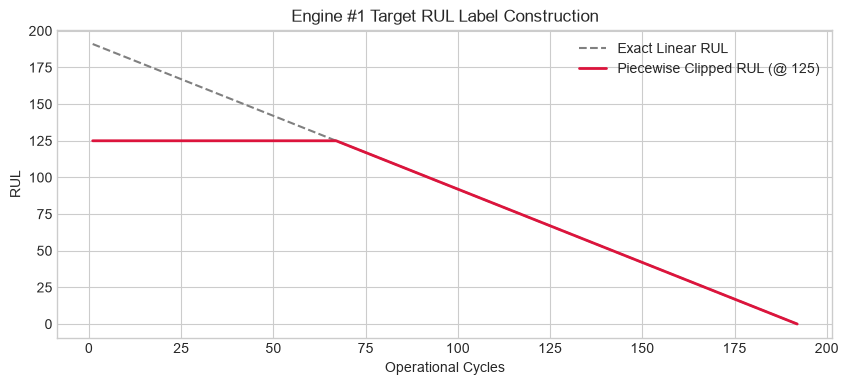

In [4]:
RUL_EARLY_CAP = 125  # Standard piece-wise linear cap threshold

def add_rul_labels(df, max_rul_cap=125):
    """Calculates exact linear and piecewise-clipped RUL for each cycle of each engine."""
    df = df.copy()
    # Max cycle per engine
    max_cycle = df.groupby('unit_nr')['time_cycles'].transform('max')
    df['RUL'] = max_cycle - df['time_cycles']
    df['RUL_clipped'] = df['RUL'].clip(upper=max_rul_cap)
    return df

train_df = add_rul_labels(train_df, max_rul_cap=RUL_EARLY_CAP)

# Visualize Piecewise Linear RUL Target for Engine #1
eng1 = train_df[train_df['unit_nr'] == 1]
plt.figure(figsize=(10, 4))
plt.plot(eng1['time_cycles'], eng1['RUL'], label='Exact Linear RUL', linestyle='--', color='gray')
plt.plot(eng1['time_cycles'], eng1['RUL_clipped'], label=f'Piecewise Clipped RUL (@ {RUL_EARLY_CAP})', color='crimson', lw=2)
plt.xlabel('Operational Cycles')
plt.ylabel('RUL')
plt.title('Engine #1 Target RUL Label Construction')
plt.legend()
plt.show()

## ⚙️ Step 3: Preprocessing & Normalization

In [5]:
# Drop constant sensors and define feature set
features = setting_cols + active_sensors

scaler = StandardScaler()
# Fit scaler only on training data
scaler.fit(train_df[features])

# Create scaled dataframes
train_scaled = train_df.copy()
train_scaled[features] = scaler.transform(train_df[features])

test_scaled = test_df.copy()
test_scaled[features] = scaler.transform(test_df[features])

print(f"Features normalized: {len(features)} channels ({len(setting_cols)} settings + {len(active_sensors)} active sensors)")

Features normalized: 17 channels (3 settings + 14 active sensors)


## 🎲 Step 4: Missingness Experiment Design (Masking Framework)

In [6]:
def inject_mcar(df, feature_cols, missing_rate=0.10, seed=42):
    """Injects Missing Completely at Random (MCAR) across specified sensor columns."""
    np.random.seed(seed)
    df_corrupted = df.copy()
    # Generate boolean mask
    mask = np.random.rand(*df[feature_cols].shape) < missing_rate
    corrupted_features = df[feature_cols].copy()
    corrupted_features[mask] = np.nan
    df_corrupted[feature_cols] = corrupted_features
    return df_corrupted, mask

def inject_block_dropout(df, feature_cols, missing_rate=0.10, min_block=5, max_block=15, seed=42):
    """Simulates telemetry burst/transmitter outages (consecutive missing cycles per engine)."""
    np.random.seed(seed)
    df_corrupted = df.copy()
    mask = np.zeros(df[feature_cols].shape, dtype=bool)
    
    # Group by unit_nr and drop random chunks of cycles
    for unit_nr, group in df.groupby('unit_nr'):
        indices = group.index.values
        n_missing_target = int(len(indices) * missing_rate)
        current_missing = 0
        
        while current_missing < n_missing_target:
            block_len = np.random.randint(min_block, max_block + 1)
            start_idx = np.random.choice(indices)
            end_pos = min(np.where(indices == start_idx)[0][0] + block_len, len(indices))
            block_indices = indices[np.where(indices == start_idx)[0][0]:end_pos]
            
            # Drop random subset of sensors during the blackout
            target_sensor_idx = np.random.choice(len(feature_cols), size=max(1, len(feature_cols)//2), replace=False)
            for b_idx in block_indices:
                row_loc = df.index.get_loc(b_idx)
                mask[row_loc, target_sensor_idx] = True
            current_missing += len(block_indices)
            
    corrupted_features = df[feature_cols].copy()
    corrupted_features[mask] = np.nan
    df_corrupted[feature_cols] = corrupted_features
    return df_corrupted, mask

# Example: Inject 15% MCAR missingness into scaled training data
train_mcar_15, mask_mcar = inject_mcar(train_scaled, active_sensors, missing_rate=0.15)
print(f"Total injected NaNs: {train_mcar_15[active_sensors].isnull().sum().sum()} (out of {train_scaled[active_sensors].size} values)")

Total injected NaNs: 43115 (out of 288834 values)


## 🛠️ Step 5: Imputation Engine Implementations

In [7]:
def impute_forward_fill(df, feature_cols):
    """Baseline 1: Trajectory-grouped Forward Fill (LOCF) with back-fill fallback."""
    df_out = df.copy()
    df_out[feature_cols] = df_out.groupby('unit_nr')[feature_cols].transform(lambda grp: grp.ffill().bfill())
    # Fallback to fleet median if entire engine sensor was missing
    df_out[feature_cols] = df_out[feature_cols].fillna(df_out[feature_cols].median())
    return df_out

def impute_linear_interpolation(df, feature_cols):
    """Baseline 2: Trajectory-grouped Linear Interpolation."""
    df_out = df.copy()
    df_out[feature_cols] = df_out.groupby('unit_nr')[feature_cols].transform(
        lambda grp: grp.interpolate(method='linear', limit_direction='both').ffill().bfill()
    )
    df_out[feature_cols] = df_out[feature_cols].fillna(df_out[feature_cols].median())
    return df_out

def impute_knn(train_df, test_df, feature_cols, n_neighbors=5):
    """Multivariate ML: K-Nearest Neighbors Imputer (fit on train, transform test)."""
    imputer = KNNImputer(n_neighbors=n_neighbors, weights='distance')
    train_out = train_df.copy()
    test_out = test_df.copy()
    train_out[feature_cols] = imputer.fit_transform(train_df[feature_cols])
    test_out[feature_cols] = imputer.transform(test_df[feature_cols])
    return train_out, test_out

def impute_mice(train_df, test_df, feature_cols, max_iter=10):
    """Multivariate ML: MICE (IterativeImputer with Bayesian Ridge)."""
    imputer = IterativeImputer(max_iter=max_iter, random_state=42)
    train_out = train_df.copy()
    test_out = test_df.copy()
    train_out[feature_cols] = imputer.fit_transform(train_df[feature_cols])
    test_out[feature_cols] = imputer.transform(test_df[feature_cols])
    return train_out, test_out

print("Imputation algorithms defined.")

Imputation algorithms defined.


## 📈 Step 6: Imputation Quality Evaluation (Direct Error Metrics)

In [8]:
# Benchmark all imputers on 15% MCAR corrupted dataset
true_vals = train_scaled[active_sensors].values[mask_mcar]

# 1. Forward fill
imp_ffill = impute_forward_fill(train_mcar_15, active_sensors)
rmse_ffill = np.sqrt(mean_squared_error(true_vals, imp_ffill[active_sensors].values[mask_mcar]))
mae_ffill = mean_absolute_error(true_vals, imp_ffill[active_sensors].values[mask_mcar])

# 2. Linear Interpolation
imp_lin = impute_linear_interpolation(train_mcar_15, active_sensors)
rmse_lin = np.sqrt(mean_squared_error(true_vals, imp_lin[active_sensors].values[mask_mcar]))
mae_lin = mean_absolute_error(true_vals, imp_lin[active_sensors].values[mask_mcar])

# 3. KNN Imputer
imp_knn, _ = impute_knn(train_mcar_15, train_mcar_15, active_sensors, n_neighbors=5)
rmse_knn = np.sqrt(mean_squared_error(true_vals, imp_knn[active_sensors].values[mask_mcar]))
mae_knn = mean_absolute_error(true_vals, imp_knn[active_sensors].values[mask_mcar])

# 4. MICE Imputer
imp_mice, _ = impute_mice(train_mcar_15, train_mcar_15, active_sensors, max_iter=5)
rmse_mice = np.sqrt(mean_squared_error(true_vals, imp_mice[active_sensors].values[mask_mcar]))
mae_mice = mean_absolute_error(true_vals, imp_mice[active_sensors].values[mask_mcar])

results_df = pd.DataFrame({
    'Imputation Method': ['Forward Fill', 'Linear Interpolation', 'KNN (k=5)', 'MICE (Iterative)'],
    'RMSE (vs True)': [rmse_ffill, rmse_lin, rmse_knn, rmse_mice],
    'MAE (vs True)': [mae_ffill, mae_lin, mae_knn, mae_mice]
})
display(results_df.sort_values(by='RMSE (vs True)'))

/opt/anaconda3/lib/python3.14/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


,Imputation Method,RMSE (vs True),MAE (vs True)
3,MICE (Iterative),0.512880,0.395455
2,KNN (k=5),0.592142,0.454763
1,Linear Interpolation,0.592554,0.450533
0,Forward Fill,0.679987,0.515549


## 🧠 Step 7 & 8: Downstream RUL Modeling & Asymmetric PHM Scoring

In [9]:
def compute_phm_score(y_true, y_pred):
    """
    NASA PHM 2008 Competition Scoring Function:
    Penalizes late predictions (d >= 0) exponentially harder than early predictions (d < 0).
    """
    d = y_pred - y_true
    score = np.where(d < 0, np.exp(-d / 13.0) - 1.0, np.exp(d / 10.0) - 1.0)
    return np.sum(score)

# Prepare sliding window features (rolling mean + std window = 20) for downstream ML
def extract_windowed_features(df, feature_cols, window_size=20):
    """Generates rolling statistical features within each engine trajectory."""
    dfs = []
    for unit_nr, group in df.groupby('unit_nr'):
        roll_mean = group[feature_cols].rolling(window=window_size, min_periods=1).mean()
        roll_std = group[feature_cols].rolling(window=window_size, min_periods=1).std().fillna(0)
        roll_mean.columns = [f'{c}_mean' for c in feature_cols]
        roll_std.columns = [f'{c}_std' for c in feature_cols]
        
        combined = pd.concat([group[['unit_nr', 'time_cycles']], roll_mean, roll_std], axis=1)
        if 'RUL_clipped' in group.columns:
            combined['RUL_clipped'] = group['RUL_clipped']
        dfs.append(combined)
    return pd.concat(dfs, axis=0).reset_index(drop=True)

print("Downstream feature extractor & PHM scoring metric ready.")

Downstream feature extractor & PHM scoring metric ready.


In [10]:
from sklearn.ensemble import RandomForestRegressor

# 1. Extract features from Clean Train and Imputed Train data
X_train_clean_df = extract_windowed_features(train_scaled, features)
feat_cols = [c for c in X_train_clean_df.columns if c not in ['unit_nr', 'time_cycles', 'RUL_clipped']]

X_train = X_train_clean_df[feat_cols]
y_train = X_train_clean_df['RUL_clipped']

# 2. Train baseline RUL Regressor
model = RandomForestRegressor(n_estimators=50, max_depth=12, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
print("Downstream RUL model trained on clean data.")

# 3. Evaluate on Clean Test Data (last observed cycle per test engine)
X_test_clean_df = extract_windowed_features(test_scaled, features)
last_cycles_clean = X_test_clean_df.groupby('unit_nr').last().reset_index()
y_pred_clean = model.predict(last_cycles_clean[feat_cols])
y_true_test = rul_test['true_rul'].values

rmse_clean_rul = np.sqrt(mean_squared_error(y_true_test, y_pred_clean))
score_clean_rul = compute_phm_score(y_true_test, y_pred_clean)

print(f"\n🎯 Baseline (Clean Test Data) -> Test RUL RMSE: {rmse_clean_rul:.2f}, PHM Score: {score_clean_rul:.2f}")

Downstream RUL model trained on clean data.

🎯 Baseline (Clean Test Data) -> Test RUL RMSE: 21.82, PHM Score: 2510.23


### 🔬 Downstream Degradation Experiment: Clean vs. Imputed Test Data

,Method,Test RUL RMSE,PHM Asymmetric Score
0,Clean Ground Truth (No Missing),21.818221,2510.231839
1,Forward Fill @ 20% Missing,22.120086,4033.962898
2,Linear Interpolation @ 20% Missing,22.368071,3994.902259
3,KNN (k=5) @ 20% Missing,22.524808,3958.519076


/var/folders/8y/n5rsl1rj65qcsz21xcjmdt680000gn/T/ipykernel_51749/459257224.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Method', y='Test RUL RMSE', data=summary_df, palette='Blues_d', ax=ax1)


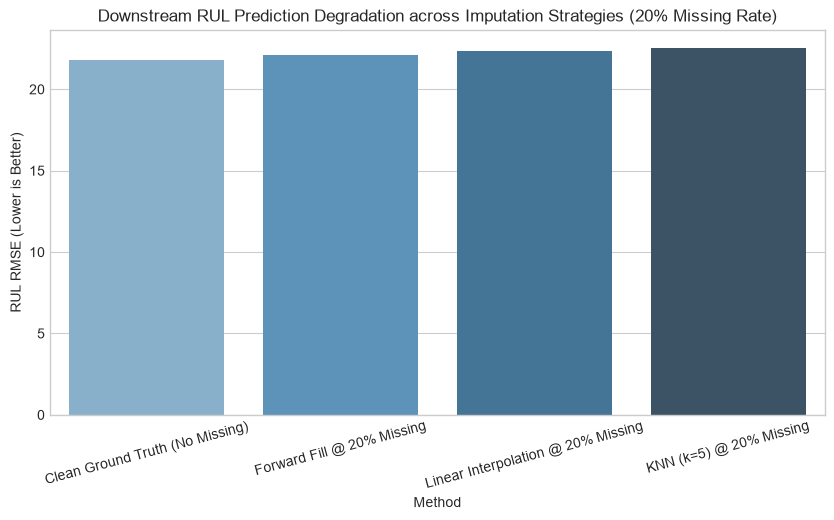

In [11]:
# Corrupt test data at 20% missingness and evaluate RUL recovery across imputers
test_corrupted_20, _ = inject_mcar(test_scaled, active_sensors, missing_rate=0.20, seed=123)

imputers = {
    'Forward Fill': impute_forward_fill(test_corrupted_20, active_sensors),
    'Linear Interpolation': impute_linear_interpolation(test_corrupted_20, active_sensors),
    'KNN (k=5)': impute_knn(train_scaled, test_corrupted_20, active_sensors)[1]
}

downstream_results = [{'Method': 'Clean Ground Truth (No Missing)', 'Test RUL RMSE': rmse_clean_rul, 'PHM Asymmetric Score': score_clean_rul}]

for name, test_imp in imputers.items():
    X_test_imp = extract_windowed_features(test_imp, features)
    last_cycles_imp = X_test_imp.groupby('unit_nr').last().reset_index()
    y_pred_imp = model.predict(last_cycles_imp[feat_cols])
    
    rmse = np.sqrt(mean_squared_error(y_true_test, y_pred_imp))
    score = compute_phm_score(y_true_test, y_pred_imp)
    downstream_results.append({'Method': f'{name} @ 20% Missing', 'Test RUL RMSE': rmse, 'PHM Asymmetric Score': score})

summary_df = pd.DataFrame(downstream_results)
display(summary_df)

# Plot comparison
fig, ax1 = plt.subplots(figsize=(10, 5))
sns.barplot(x='Method', y='Test RUL RMSE', data=summary_df, palette='Blues_d', ax=ax1)
ax1.set_title('Downstream RUL Prediction Degradation across Imputation Strategies (20% Missing Rate)')
ax1.set_ylabel('RUL RMSE (Lower is Better)')
plt.xticks(rotation=15)
plt.show()